# Polynomial Regression

In [52]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go

In [53]:
np.random.seed(42)
n = 1000

feat_1 = np.random.uniform(-3, 3, n)
feat_2 = np.random.uniform(-3, 3, n)
feat_3 = np.random.uniform(-3, 3, n)

# Non-linear target: quadratic + interaction + sine + noise
target = (
    2.0 * feat_1**2
    - 1.5 * feat_2**2
    + 2.5 * feat_1 * feat_3
    + 1.8 * np.sin(feat_2)
    + np.random.randn(n) * 0.3
)

df = pd.DataFrame({
    'feat_1': feat_1,
    'feat_2': feat_2,
    'feat_3': feat_3,
    'target': target
})

X = df[['feat_1', 'feat_2', 'feat_3']]
y = df['target']

X = df[['feat_1', 'feat_2', 'feat_3']]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

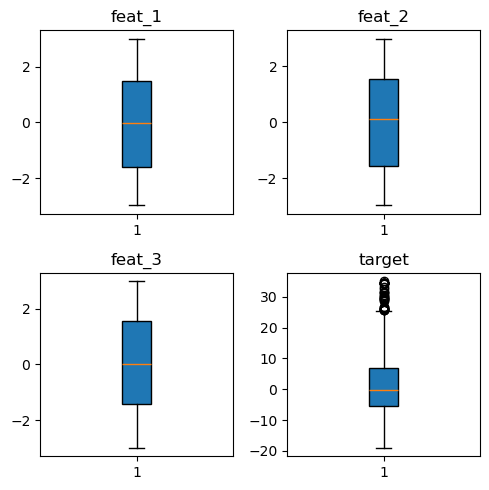

In [54]:
fig, axes = plt.subplots(2, 2, figsize=(5, 5))

for ax, col in zip(axes.flatten(), df.columns):
    ax.boxplot(df[col], patch_artist=True)
    ax.set_title(col)

plt.tight_layout()
plt.show()

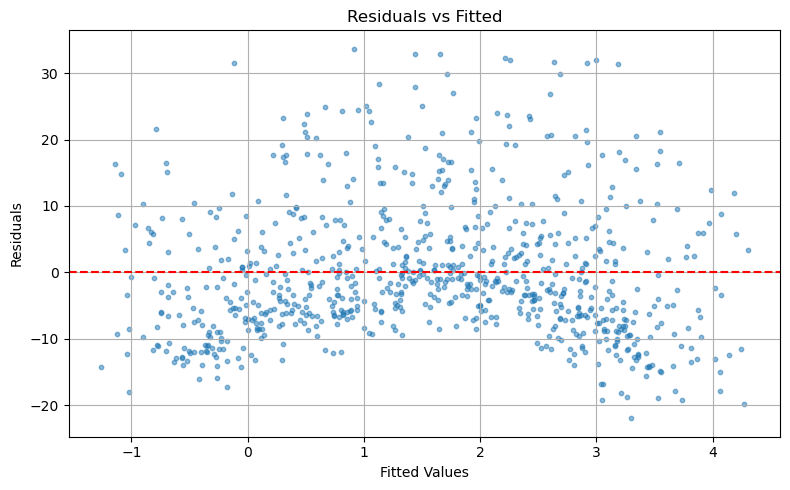

In [55]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_train)
residuals = y_train - y_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.5, s=10)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted')
plt.grid(True)
plt.tight_layout()
plt.show()

Realação não linear entre preditores e alvo, modelo é enviesado (underfit) caso não se introduzam termos polinomiais, se o grau for muito grande o viés reduz abruptamente mas o modelo se torna muito sensível (overfit)

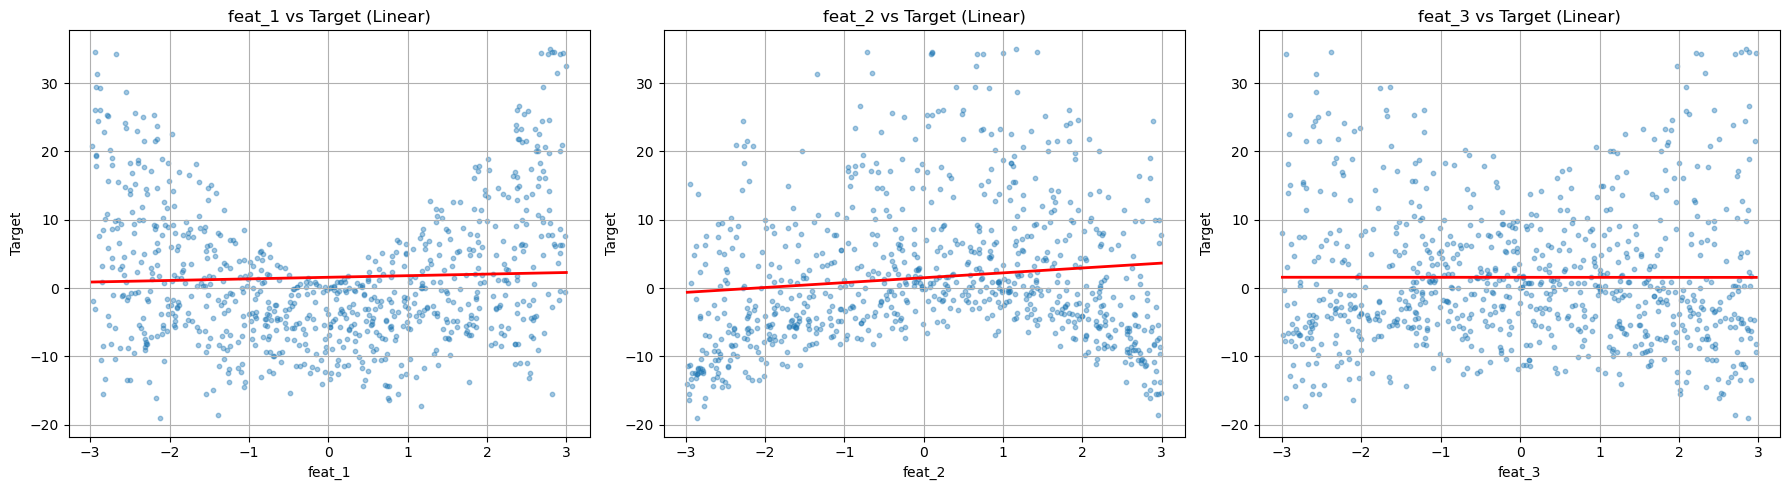

In [56]:
linear_model = Pipeline([
    ('std', StandardScaler()),
    ('model', LinearRegression())
])
linear_model.fit(X_train, y_train)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
feature_names = ['feat_1', 'feat_2', 'feat_3']
X_mean = X_train.mean().values

for ax, feat_idx, feat_name in zip(axes, range(3), feature_names):
    ax.scatter(X_train.iloc[:, feat_idx], y_train, alpha=0.4, s=10)

    x_range = np.linspace(X_train.iloc[:, feat_idx].min(), X_train.iloc[:, feat_idx].max(), 100)
    X_grid = pd.DataFrame(np.tile(X_mean, (100, 1)), columns=X_train.columns)
    X_grid.iloc[:, feat_idx] = x_range

    y_grid = linear_model.predict(X_grid)
    ax.plot(x_range, y_grid, color='red', linewidth=2)

    ax.set_xlabel(feat_name)
    ax.set_ylabel('Target')
    ax.set_title(f'{feat_name} vs Target (Linear)')
    ax.grid(True)

plt.tight_layout()
plt.show()

Dados originais, reta se ajusta de forma linear, pois todos os dados são lineares: x^1

## Training

In [57]:
param_grid = [
    {
        "poly__degree": [1, 2, 3, 4, 5],
        "model": [LinearRegression()],
        "model__fit_intercept": [True, False],
    },
    {
        "poly__degree": [1, 2, 3, 4, 5],
        "model": [Ridge()],
        "model__alpha": [0.01, 0.1, 1.0, 10.0, 100.0],
        "model__fit_intercept": [True, False],
        "model__solver": ["auto", "svd", "cholesky", "lsqr"],
    },
    {
        "poly__degree": [1, 2, 3, 4, 5],
        "model": [Lasso(max_iter=10000)],
        "model__alpha": [0.0001, 0.001, 0.01, 0.1, 1.0],
        "model__fit_intercept": [True, False],
        "model__selection": ["cyclic", "random"],
    },
    {
        "poly__degree": [1, 2, 3, 4, 5],
        "model": [ElasticNet(max_iter=10000)],
        "model__alpha": [0.0001, 0.001, 0.01, 0.1, 1.0],
        "model__l1_ratio": [0.2, 0.5, 0.8],
        "model__fit_intercept": [True, False],
        "model__selection": ["cyclic", "random"],
    },
]

In [58]:
pipe = Pipeline([
    ('poly', PolynomialFeatures(include_bias=False)),
    ('std', StandardScaler()),
    ('model', LinearRegression())
])

grid = GridSearchCV(pipe, param_grid, cv=5, scoring='r2', return_train_score=True, n_jobs=-1)
grid.fit(X_train, y_train)


,estimator,Pipeline(step...egression())])
,param_grid,"[{'model': [LinearRegression()], 'model__fit_intercept': [True, False], 'poly__degree': [1, 2, ...]}, {'model': [Ridge()], 'model__alpha': [0.01, 0.1, ...], 'model__fit_intercept': [True, False], 'model__solver': ['auto', 'svd', ...], ...}, ...]"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,degree,5


In [59]:
print(f'Best params: {grid.best_params_}')
print(f'Best CV R²:  {grid.best_score_:.4f}')

Best params: {'model': Lasso(max_iter=10000), 'model__alpha': 0.001, 'model__fit_intercept': True, 'model__selection': 'cyclic', 'poly__degree': 5}
Best CV R²:  0.9991


## Diagnostic

In [60]:
final_model = grid.best_estimator_

final_model.fit(X_train, y_train)

,steps,"[('poly', ...), ('std', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,degree,5
,interaction_only,False
,include_bias,False
,order,'C'
,copy,True
,with_mean,True
,with_std,True


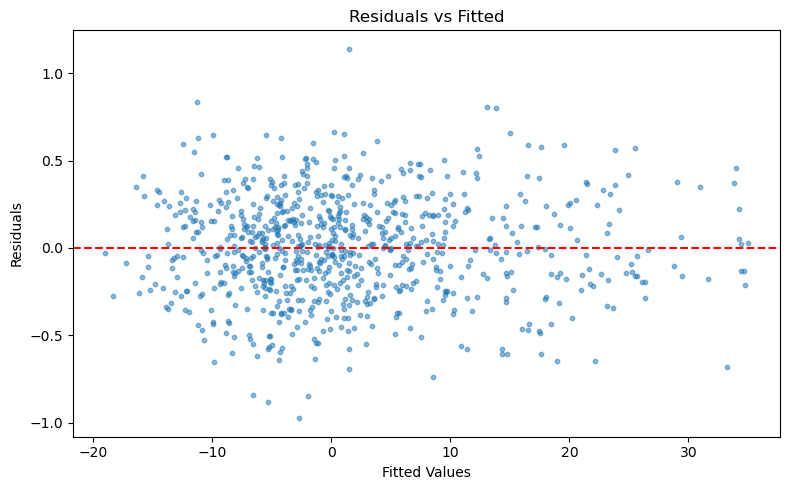

In [61]:
y_pred = final_model.predict(X_train)
residuals = y_train - y_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.5, s=10)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted')
plt.tight_layout()
plt.show()

Em multiplas dimensões, os pontos descrevem-se junto a reta de regressão, mas reduzindo a dimensão, a representação passa a ser uma curva

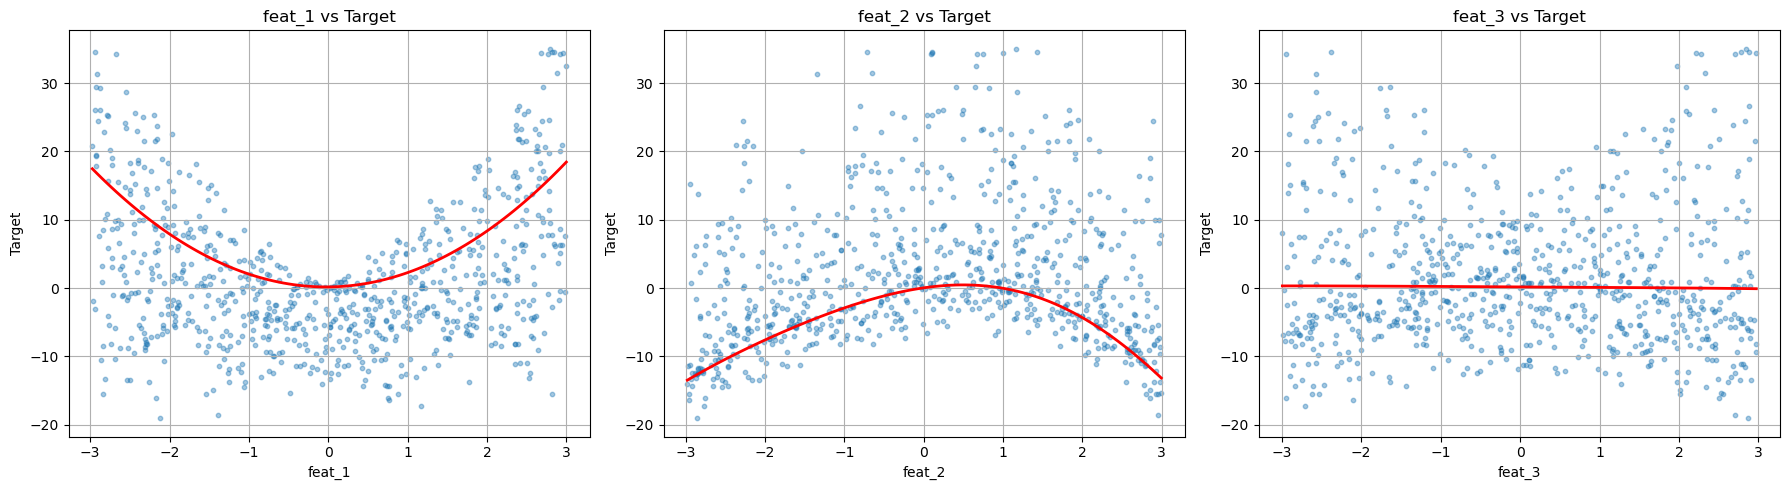

In [62]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
feature_names = ['feat_1', 'feat_2', 'feat_3']
X_mean = X_train.mean().values

for ax, feat_idx, feat_name in zip(axes, range(3), feature_names):
    # Scatter: feature vs target
    ax.scatter(X_train.iloc[:, feat_idx], y_train, alpha=0.4, s=10)

    # Regression line: vary one feature, keep others at mean
    x_range = np.linspace(X_train.iloc[:, feat_idx].min(), X_train.iloc[:, feat_idx].max(), 100)
    X_grid = pd.DataFrame(np.tile(X_mean, (100, 1)), columns=X_train.columns)
    X_grid.iloc[:, feat_idx] = x_range

    y_grid = final_model.predict(X_grid)
    ax.plot(x_range, y_grid, color='red', linewidth=2)

    ax.set_xlabel(feat_name)
    ax.set_ylabel('Target')
    ax.set_title(f'{feat_name} vs Target')
    ax.grid(True)

plt.tight_layout()
plt.show()

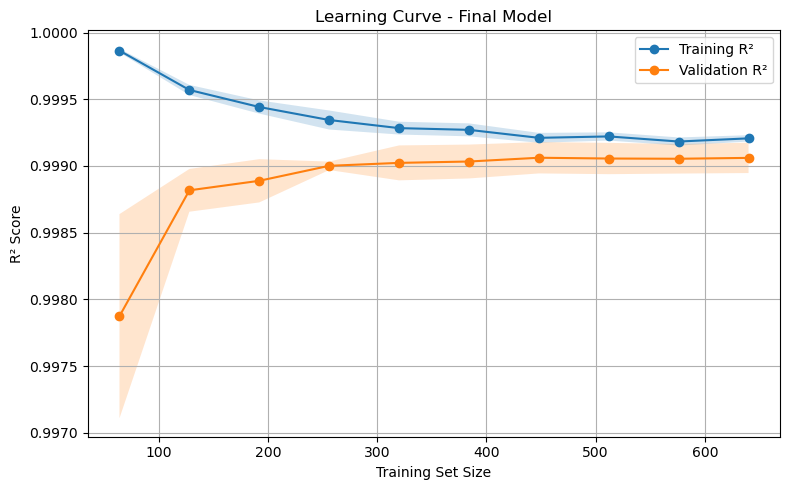

In [63]:
train_sizes, train_scores, val_scores = learning_curve(
    final_model, X_train, y_train, cv=5, scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, 'o-', label='Training R²')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)
plt.plot(train_sizes, val_mean, 'o-', label='Validation R²')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2)
plt.xlabel('Training Set Size')
plt.ylabel('R² Score')
plt.title('Learning Curve - Final Model')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Ambos convergem relativamente bem, sem under ou overfit claro

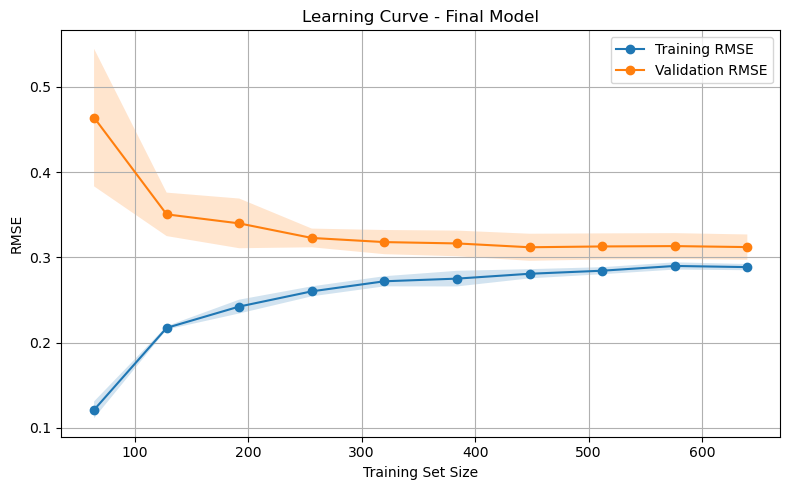

In [64]:
train_sizes, train_scores, val_scores = learning_curve(
    final_model,
    X_train,
    y_train,
    cv=5,
    scoring="neg_root_mean_squared_error",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = -train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = -val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

plt.figure(figsize=(8, 5))

plt.plot(train_sizes, train_mean, "o-", label="Training RMSE")
plt.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.2
)

plt.plot(train_sizes, val_mean, "o-", label="Validation RMSE")
plt.fill_between(
    train_sizes,
    val_mean - val_std,
    val_mean + val_std,
    alpha=0.2
)

plt.xlabel("Training Set Size")
plt.ylabel("RMSE")
plt.title("Learning Curve - Final Model")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

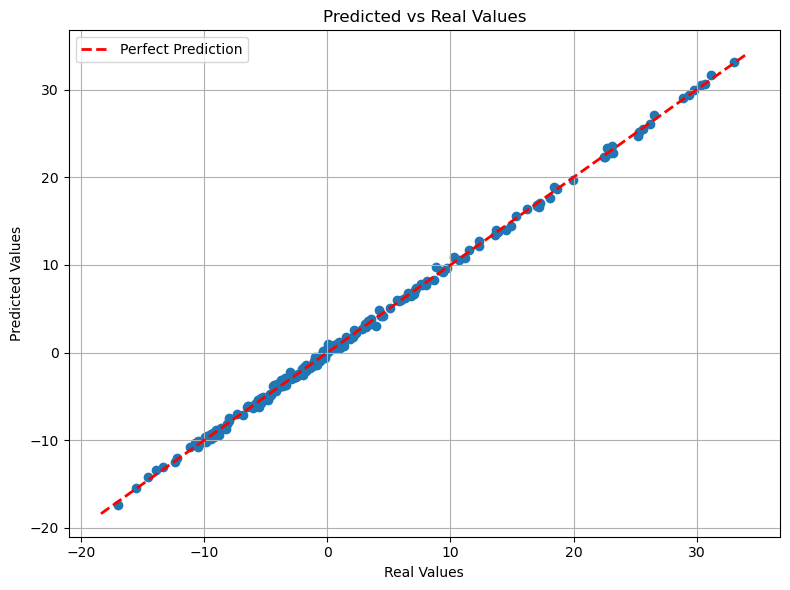

In [65]:
y_pred_test = final_model.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_test)

lims = [min(y_test.min(), y_pred_test.min()) - 1, max(y_test.max(), y_pred_test.max()) + 1]
plt.plot(lims, lims, 'r--', linewidth=2, label='Perfect Prediction')

plt.xlabel('Real Values')
plt.ylabel('Predicted Values')
plt.title('Predicted vs Real Values')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Predição quase perfeita no conjunto de teste

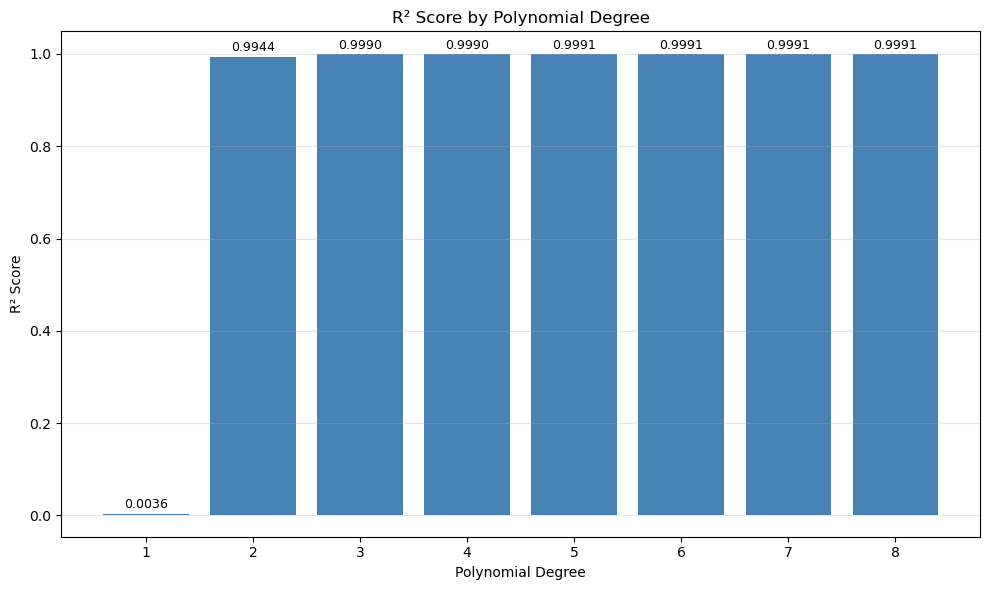

In [66]:
degrees = list(range(1,9))
r2_scores = []
bias = False

for degree in degrees:
    pipe = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('std', StandardScaler()),
        ('model', Lasso(alpha=0.001, max_iter=10000, fit_intercept=True, selection='cyclic'))
    ])
    pipe.fit(X_train, y_train)
    r2 = pipe.score(X_test, y_test)
    r2_scores.append(r2)

plt.figure(figsize=(10, 6))
bars = plt.bar([str(d) for d in degrees], r2_scores, color='steelblue')
for bar, r2 in zip(bars, r2_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{r2:.4f}', ha='center', va='bottom', fontsize=9)
plt.xlabel('Polynomial Degree')
plt.ylabel('R² Score')
plt.title('R² Score by Polynomial Degree')
plt.ylim(min(r2_scores) - 0.05, max(r2_scores) + 0.05)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Usar d=2 seria mais vantajoso, por acelerar o modelo significativamente sem quase nenhuma perda

In [67]:
poly = final_model.named_steps['poly']
lasso = final_model.named_steps['model']

feature_names = poly.get_feature_names_out(X_train.columns)
coefs = lasso.coef_

kept = sorted([(name, coef) for name, coef in zip(feature_names, coefs) if coef != 0],
              key=lambda x: abs(x[1]), reverse=True)
removed = [name for name, coef in zip(feature_names, coefs) if coef == 0]

print(f'Kept features ({len(kept)}):')
for name, coef in kept:
    print(f'  {name}: {coef:.4f}')

print(f'\nRemoved features ({len(removed)}):')
for name in removed:
    print(f'  {name}')

Kept features (44):
  feat_1 feat_3: 7.4748
  feat_1^2: 5.3115
  feat_2^2: -4.0917
  feat_2: 2.9232
  feat_2^3: -2.5217
  feat_2^5: 0.5286
  feat_1^2 feat_2: -0.0497
  feat_1^4 feat_3: 0.0341
  feat_1^2 feat_3^3: -0.0334
  feat_1^2 feat_2 feat_3^2: 0.0307
  feat_2^3 feat_3^2: -0.0305
  feat_1^3 feat_3: 0.0285
  feat_1^3 feat_2: 0.0272
  feat_1^4 feat_2: 0.0252
  feat_2 feat_3: 0.0233
  feat_2^2 feat_3^3: 0.0230
  feat_1^2 feat_2^3: 0.0207
  feat_1^3 feat_2^2: 0.0179
  feat_1 feat_2^2 feat_3: 0.0177
  feat_1^4: 0.0164
  feat_2^4: 0.0164
  feat_3^4: -0.0164
  feat_2^2 feat_3^2: -0.0153
  feat_2^4 feat_3: -0.0152
  feat_1^3 feat_2 feat_3: 0.0144
  feat_1 feat_2^2: -0.0141
  feat_1 feat_2 feat_3^2: -0.0138
  feat_1^2 feat_2 feat_3: -0.0131
  feat_1 feat_2^4: -0.0124
  feat_1 feat_2^2 feat_3^2: -0.0102
  feat_1^2 feat_3: 0.0088
  feat_2 feat_3^2: 0.0085
  feat_1 feat_2^3: -0.0076
  feat_1^2 feat_2^2 feat_3: -0.0068
  feat_2^2 feat_3: -0.0059
  feat_1^2 feat_2^2: 0.0049
  feat_1^3: 0.0047
  

A vantagem do lasso é que basta aplicar transformação polinomial em todos, e ele trata de decidir quais são boas ou não. Caso contrario deveria se decidir um a um, e usar colum transformer para aplicar o poly de forma ordenada

## 3D Regression Plane

In [70]:
DEGREE = grid.best_params_['poly__degree']

poly = PolynomialFeatures(degree=DEGREE, include_bias=False)
X_poly = poly.fit_transform(X_train)

best_model = grid.best_estimator_['model']
reg_high = LinearRegression().fit(X_poly, y_train)

feat_a, feat_b = 0, 1

a_range = np.linspace(X_poly[:, feat_a].min(), X_poly[:, feat_a].max(), 30)
b_range = np.linspace(X_poly[:, feat_b].min(), X_poly[:, feat_b].max(), 30)
a_grid, b_grid = np.meshgrid(a_range, b_range)

grid_points = np.zeros((30 * 30, X_poly.shape[1]))
grid_points[:, feat_a] = a_grid.ravel()
grid_points[:, feat_b] = b_grid.ravel()

mean_vals = X_poly.mean(axis=0)
for i in range(X_poly.shape[1]):
    if i not in [feat_a, feat_b]:
        grid_points[:, i] = mean_vals[i]

z_pred = reg_high.predict(grid_points).reshape(30, 30)

fig = go.Figure()

fig.add_trace(go.Scatter3d(
    x=X_poly[:, feat_a], y=X_poly[:, feat_b], z=y_train.values,
    mode='markers',
    marker=dict(size=3, color=y_train.values, colorscale='Viridis', opacity=0.6),
    name='Data points'
))

fig.add_trace(go.Surface(
    x=a_grid, y=b_grid, z=z_pred,
    colorscale='Reds', opacity=0.5,
    name='Regression plane'
))

feature_names_poly = poly.get_feature_names_out()
fig.update_layout(
    scene=dict(
        xaxis_title=feature_names_poly[feat_a],
        yaxis_title=feature_names_poly[feat_b],
        zaxis_title='Target'
    ),
    height=700, width=900,
    title=f'Regression Plane (degree={DEGREE}) in High-Dimensional Space'
)
fig.show()